# Credit Card Fraud Detection Using Machine Learning

## Executive Summary
This project develops a machine learning model to detect fraudulent credit card transactions using an online dataset of 284,807 cardholder transactions. The dataset is highly unbalanced with only 0.17% of transactions being frauds.

#### Key Results:
- **Model**: Random Forest Classifier
- **Recall**: 88.8% - successfully catches 87 out of 98 frauds
- **Precision**: 87.9% - 12% of flagged transactions are false alarms
- **F1-Score**: 88.3%

## Business Problem
Credit card fraud can cost financial company millions every year. Traditional systems works but may introduce too much false positives, legitimate customers flagged as fraud. Machine learning offers an apporach to:
1. accurately identify fraudulent transactions
2. minimize false positives

## Dataset
- **Source**: Kaggle Credit Card Fraud Detection dataset
- **Total Transactions**: 284,807
- **Legitimate**: 284,315
- **Fraud**: 492


### Key Features:
- **Time**: Seconds elapsed from the first transaction record
- **V1-V28**: PCA-transformed features
- **Amount**: transaction amount
- **Class**: 0 (legitimate) or 1 (fraud)

## Project Approach
1. **Exploratory Data Analysis**: Understand patterns and feature distributions
2. **Data Preprocessing**: Feature engineering and handling class imbalance with SMOTE
3. **Model Selection**: Compare 4 classification algorithms
4. **Hyperparameter Tuning**: Optimize best-performing model
5. **Evaluation**: Asses performance with approriate metrics

## A. Exploratory Data Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('creditcard.csv')

#basic info
print(f"Data Shape: {data.shape}")
print(f"\nClass DIstribution:")
print(data['Class'].value_counts())

Data Shape: (284807, 31)

Class DIstribution:
Class
0    284315
1       492
Name: count, dtype: int64


### Key Findings from EDA

#### 1. Severe Class Imbalance
- Imbalance ratio (legitimate:fraud) = 580:1
- Standard accuracy metric is meaningless, this project will be using other metrics including recall, precision, and f1-score

In [3]:
print("Fraud Rate")
print(f"{data['Class'].mean()*100:.2f}%")

Fraud Rate
0.17%


#### 2. Transaction Amount Patterns

In [4]:
#amount distribution
amount_bins = [0, 10, 50, 100, 500, 1000, 25000]
data['amount_bin'] = pd.cut(data['Amount'], bins = amount_bins)

print("Amount Distribution")
data.groupby('amount_bin', observed=False)['Amount'].agg(['count','mean','median','std','min','max'])

Amount Distribution


,count,mean,median,std,min,max
amount_bin,,,,,,
"(0, 10]",98439,3.960584,2.580,3.235288,0.01,10.00
"(10, 50]",90781,25.959312,23.660,11.781346,10.01,50.00
"(50, 100]",37254,73.297092,71.880,14.686627,50.01,100.00
"(100, 500]",47366,212.596131,179.425,100.667599,100.01,500.00
"(500, 1000]",6202,693.381743,663.180,142.268986,500.04,1000.00
"(1000, 25000]",2939,1799.802252,1435.000,1144.384755,1000.10,19656.53


In [5]:
#fraud distribution
print("Fraud Distribution")
data[data['Class']==1].groupby('amount_bin', observed=False).size()

Fraud Distribution


amount_bin
(0, 10]          222
(10, 50]          57
(50, 100]         56
(100, 500]        95
(500, 1000]       26
(1000, 25000]      9
dtype: int64

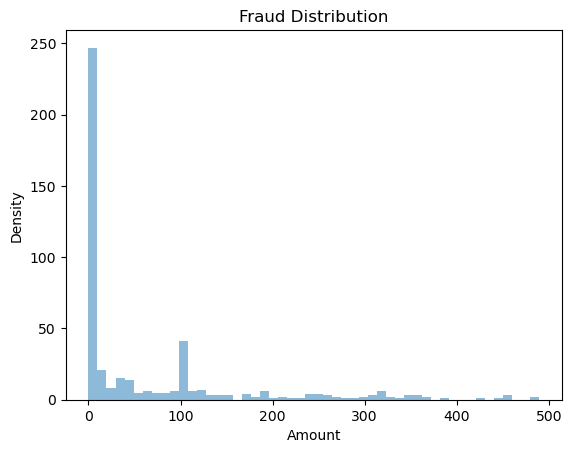

In [6]:
#smaller range for better visual
data_500 = data[data['Amount'] <= 500]

plt.hist(data_500[data_500['Class']==1]['Amount'], bins = 50, alpha=0.5)
plt.xlabel('Amount')
plt.ylabel('Density')
plt.title('Fraud Distribution')
plt.show()

**Key Insights**: Most fraud amounts concentrated in the 0-10 range. This is logically makes sense since the fraudsters may test the stolen card first before attempting larger purchase. 

#### 3. Time Patterns

Data spans over 48.0 hours (2 days)


Text(0.5, 1.0, 'Fraud Rate Over Time')

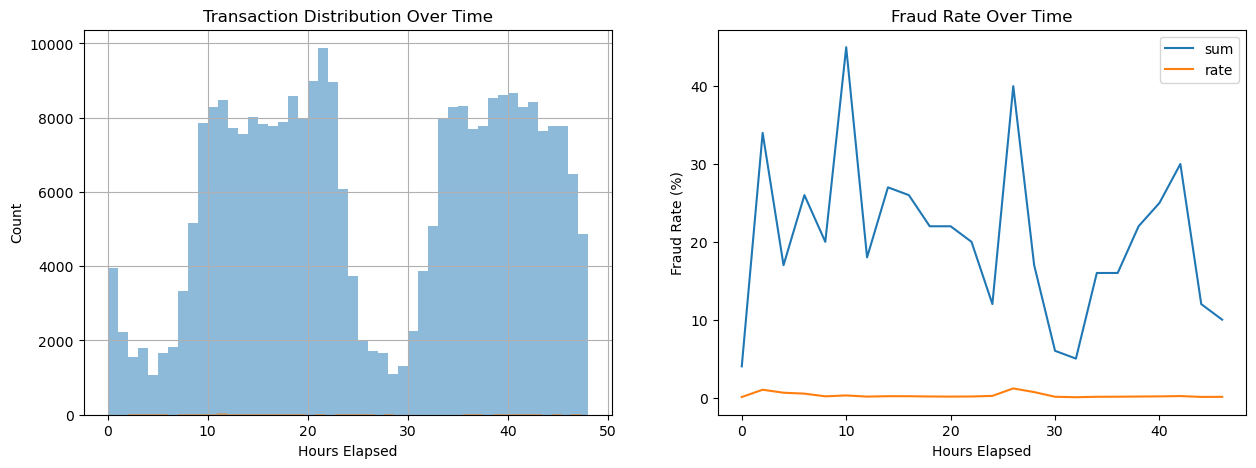

In [7]:
data['hours_elapsed'] = data['Time']/3600

#collection period
print(f'Data spans over {data['hours_elapsed'].max():.1f} hours \
({data['hours_elapsed'].max()/24:.0f} days)')

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
data[data['Class']==0]['hours_elapsed'].hist(bins=48, alpha=0.5, label='Legitimate')
data[data['Class']==1]['hours_elapsed'].hist(bins=48, alpha=0.5, label='Fraud')
plt.xlabel('Hours Elapsed')
plt.ylabel('Count')
plt.title('Transaction Distribution Over Time')

plt.subplot(1,2,2)
data['hour_bin'] = (data['hours_elapsed'] // 2) * 2 #create 2 hour bins
fraud_rate = data.groupby('hour_bin')['Class'].agg(['sum', 'count'])
fraud_rate['rate'] = fraud_rate['sum']/fraud_rate['count'] * 100
fraud_rate[['sum', 'rate']].plot(ax=plt.gca())
plt.xlabel('Hours Elapsed')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate Over Time')

In [8]:
fraud_rate.sort_values('rate', ascending=False)

,sum,count,rate
hour_bin,,,
26.0,40,3423,1.168566
2.0,34,3397,1.000883
28.0,17,2436,0.697865
4.0,17,2763,0.615273
6.0,26,5199,0.500096
10.0,45,16805,0.267777
24.0,12,5735,0.209241
42.0,30,16087,0.186486
14.0,27,15865,0.170186


**Key Insights**: Most transactions happened during busy/work hours until midnight (10 AM - 12 AM). Fraud activity spikes during early morning hours, peaked at 2-4 AM, when legitimate transaction activity is actually low. This suggests fraudsters operate during off-hours when the actual cardholders are less likely to notice unauthorized charges immediately.

#### 4. Feature Correlations

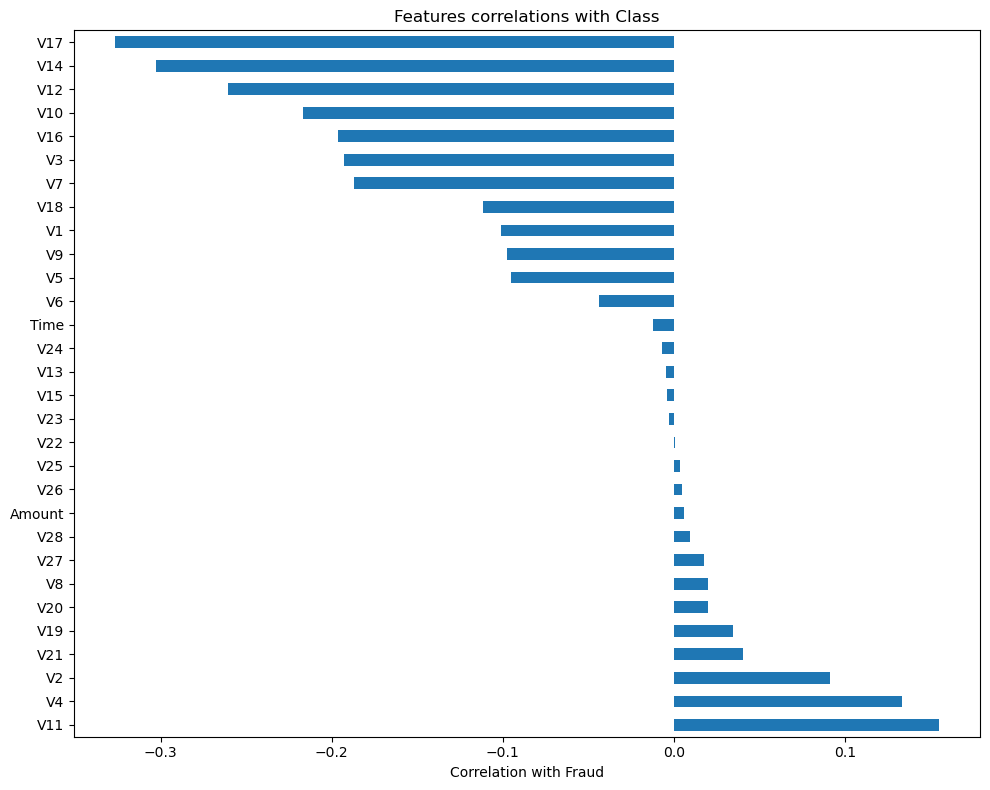

In [9]:
correlations = data.iloc[:,0:31].corr()['Class'].drop('Class').sort_values(ascending=False)

plt.figure(figsize=(10,8))
correlations.plot(kind='barh')
plt.xlabel('Correlation with Fraud')
plt.title('Features correlations with Class')
plt.tight_layout()
plt.show()

In [10]:
print('Positively correlated')
correlations.head()

Positively correlated


V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

In [11]:
print("Negatively correlated")
correlations.tail()

Negatively correlated


V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64

**Key Insights**: None of the features have a strong correlation with the class target. The strongest correlation is only 32.6% correlated. Time & Amount features, two features not PCA transformed, also showing very weak correlations

#### 5. PCA Features

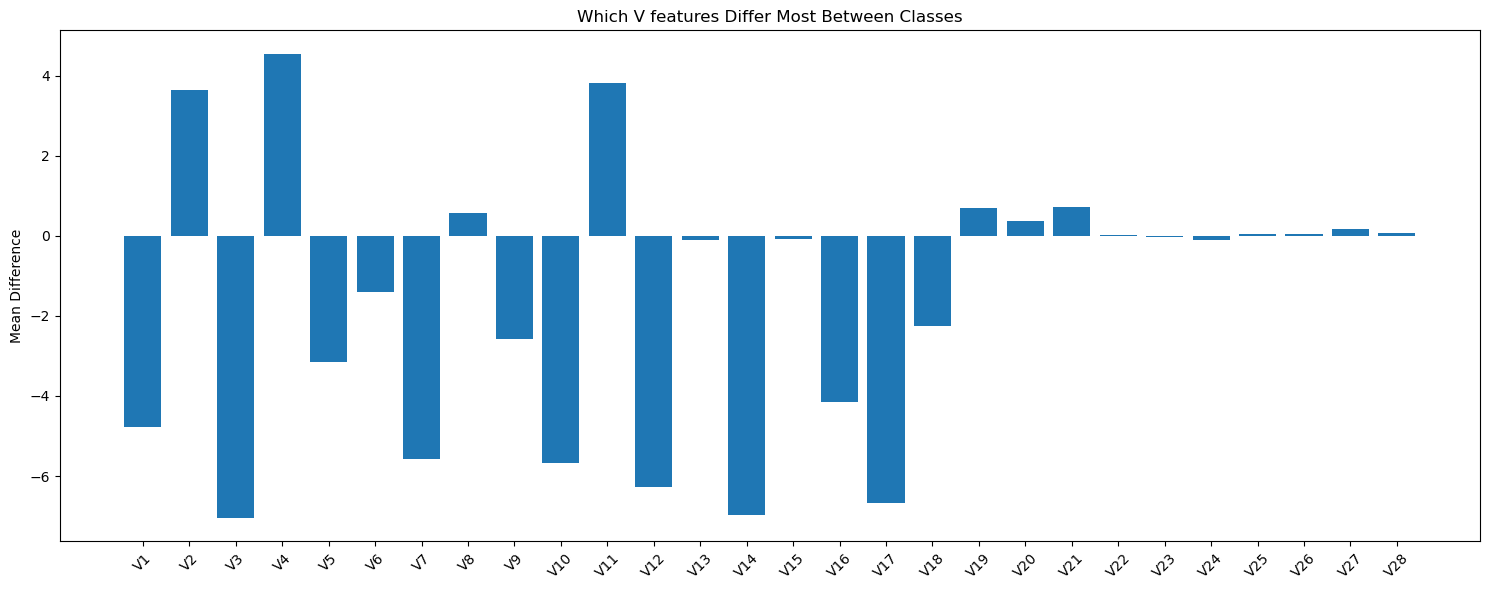

In [12]:
v_features = data.iloc[:, 1:29].columns

fraud_means = data[data['Class']==1][v_features].mean()
legit_means = data[data['Class']==0][v_features].mean()

fig, ax = plt.subplots(figsize=(15,6))
x = range(len(v_features))
ax.bar(x, fraud_means - legit_means)
ax.set_xticks(x)
ax.set_xticklabels(v_features, rotation=45)
ax.set_ylabel('Mean Difference')
ax.set_title('Which V features Differ Most Between Classes')
plt.tight_layout()
plt.show()

**Key Insights**: High difference shows large information difference between classes. Little to no difference suggests some features have similar data between legitimate and fraud. These features are considered to be removed

## B. Data Preprocessing

### V-Features Reduction

Previous exploration suggests the PCA transformed features (V-features) are enough for a good performance and doing features engineering or adding new features didn't improve the results. Moreover, several V-features doesn't hold much information and removing them didn't reduce the performance as well.

In [27]:
#reset original data
data = pd.read_csv('creditcard.csv')

#reduce v
low_score_v = ['V22', 'V23', 'V25', 'V26', 'V28', 'V15', 'V24', 'V13', 'V27']

reduced_v = data.drop(columns=low_score_v)
X = reduced_v.drop('Class', axis=1)
y = reduced_v['Class']

### Train-Test Split

We used stratified split to maintain the same class distribution in both train and test sets.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Train set: (227845, 21)
Test set: (56962, 21)


### Handling Class Imbalance
Tested five approaches to address the class imbalance

In [15]:
imbalance_comparison = pd.DataFrame({
    'Technique': ['Baseline (No Handling)', 'Random Undersampling', 'SMOTE', 'SMOTE TOMEK',
                  'SMOTE ENN', 'Class Weights'],
    'Precision': [0.93, 0.07, 0.87, 0.87, 0.83, 0.92], 
    'Recall': [0.85, 0.91, 0.88, 0.88, 0.88, 0.85],
    'F1-Score': [0.89, 0.12, 0.87, 0.87, 0.86, 0.88]
})

print(imbalance_comparison.to_string(index=False))

             Technique  Precision  Recall  F1-Score
Baseline (No Handling)       0.93    0.85      0.89
  Random Undersampling       0.07    0.91      0.12
                 SMOTE       0.87    0.88      0.87
           SMOTE TOMEK       0.87    0.88      0.87
             SMOTE ENN       0.83    0.88      0.86
         Class Weights       0.92    0.85      0.88


**Analysis:**
- Random Undersampling: achieved the highest recall of 90% but the rest is miserable with precision 7% and f1-score 12%
- SMOTE: gave better improvement on recall score 88% but with a slight trade off of precision 87% and f1-score 87%
- SMOTE + Tomek have the same result as SMOTE and SMOTE + ENN have the same recall as SMOTE but with lower precision & f1 score
- Class weights have the same recall as baseline but with lower precision and f1 scoreline

**Decision**: Selected **SMOTE** (Synthetic Minority Oversampling Technique) because:
1. Improves recall from 85% to 88% (+3% more frauds caught)
2. Maintains acceptable precisi
3. In fraud detection, the cost of missing a fraud (false negative) typically outweights the cost of false alarms (false positive), so the trade off are justifiable

In [30]:
#apply SMOTE
from imblearn.over_sampling import SMOTE

smote_sample = SMOTE(random_state=1)
X_train_resampled, y_train_resampled  = smote_sample.fit_resample(X_train, y_train)

print(f"Before SMOTE: {len(X_train):,} samples")
print(f"After SMOTE: {len(X_train_resampled):,} samples")
print(f"Class distribution: {y_train_resampled.value_counts().to_dict()}")

Before SMOTE: 227,845 samples
After SMOTE: 454,902 samples
Class distribution: {0: 227451, 1: 227451}


Using SMOTE oversampling, the fraud data is oversampled to have the same quantity as the legitimate one

## C. Model Comparison

Compared 4 classification algorithms with reasonable starting parameter.

In [17]:
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'Precision': [0.11, 0.37, 0.83, 0.01], 
    'Recall': [0.91, 0.87, 0.88, 0.53],
    'F1-Score': [0.20, 0.51, 0.85, 0.04],
    'Training Time (s)': [39, 40, 72, 0.10]
})

print("\nModel Performance Comparison:")
print(model_results.to_string(index=False))


Model Performance Comparison:
              Model  Precision  Recall  F1-Score  Training Time (s)
Logistic Regression       0.11    0.91      0.20               39.0
      Decision Tree       0.37    0.87      0.51               40.0
      Random Forest       0.83    0.88      0.85               72.0
                KNN       0.01    0.53      0.04                0.1


### Model Selection

**Analysis:**
- Logistic Regression: has the best recall score but with much worse f1 score of 20% and precision of 11%
- Decision tree performed better than logistic regression but the precision and f1 score are too low to be considered.
- Random Forest performed best with recall score 88%, precision 83%, and f1-score 85%
- KNN performed very poorly overall

**Decision**: Selected **Random Forest**, reasons:
1. Best performance
2. Catches most frauds
3. Reasonable training time

**Note on Computational Constraints**: SVM was also considered for model comparison but it was later dismissed because 455000 data after SMOTE resampled would require tremendous amount of hours just for 1 train-test.

## Hyperparameter Tuning

Performed random search with Random Forest as the base model to optimize recall

### Random & Grid Search

#### Parameter Random Tested:
- **n_estimators**: [100, 200, 300]
- **max_depth**: [10, 15, 20]
- **min_samples_split**: [2, 5, 10]
- **max_features**: ['sqrt', 'log2']
- **bootstrap**: [True]

**Number of Iterations**: 30 
**Cross-validation**: 3-fold stratified
**Total Combinations**: 90
**Optimization metric**: Recall  
**Training time**: 98.5 minutes

In [18]:
best_params = {
    'n_estimators': 300, 
    'max_depth': 10,
    'min_samples_split': 10,
    'max_features': 'log2',
    'bootstrap': True
}

print("Best Parameters Found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

Best Parameters Found:
  n_estimators: 300
  max_depth: 10
  min_samples_split: 10
  max_features: log2
  bootstrap: True


Before testing, we further validate the best parameters using grid search using value near the best parameters. We still using recall as the score metric

#### Parameter Grid Tested
- **n_estimators**: [250, 300, 350]
- **max_depth**: [7, 10, 13]
- **min_samples_split**: [8, 10, 12]
- **max_features**: ['log2']
- **bootstrap**: [True]
- **Cross-validation**: 3-fold stratified

In [19]:
best_params = {
    'n_estimators': 300, 
    'max_depth': 7,
    'min_samples_split': 8,
    'max_features': 'log2',
    'bootstrap': True
}

print("New Best Parameters Found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

New Best Parameters Found:
  n_estimators: 300
  max_depth: 7
  min_samples_split: 8
  max_features: log2
  bootstrap: True


#### Comparison with Baseline

In [20]:
tuning_results = pd.DataFrame({
    'Model': ['Baseline RF', 'Tuned RF'],
    'Precision': [0.88, 0.41],
    'Recall': [0.89, 0.91],
    'F1-Score': [0.88, 0.26]
})

print(tuning_results.to_string(index=False))

      Model  Precision  Recall  F1-Score
Baseline RF       0.88    0.89      0.88
   Tuned RF       0.41    0.91      0.26


### Tuning Results

**Finding**: Hyperparameter tuning confirmed the baseline parameters were already optimal for this dataset. The best parameters from random & grid search improved the recall but performed way worse on both f1 score and precision.

**Interpretation**: This validates that:
1. Modern default Random Forest parameters are highly effective for fraud detection
2. The feature set (PCA-transformed V1-V28) already contain enough informations
3. SMOTE effectively addressed the class imbalance
4. Further gains would require feature engineering or ensemble methods

The baseline model is adopted as the final model.

## Final Model Performance

### Test Set Results

In [34]:
from sklearn.ensemble import RandomForestClassifier

final_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    bootstrap = True,
    random_state = 1,
    n_jobs = -1    
)

final_model.fit(X_train_resampled, y_train_resampled)
y_pred = final_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report")
print(classification_report(y_pred, y_test, target_names = ['Legitimate', 'Fraud']))

print("Confusion Matrix")
print(confusion_matrix(y_pred, y_test))

Classification Report
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       0.89      0.88      0.88        99

    accuracy                           1.00     56962
   macro avg       0.94      0.94      0.94     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix
[[56852    11]
 [   12    87]]


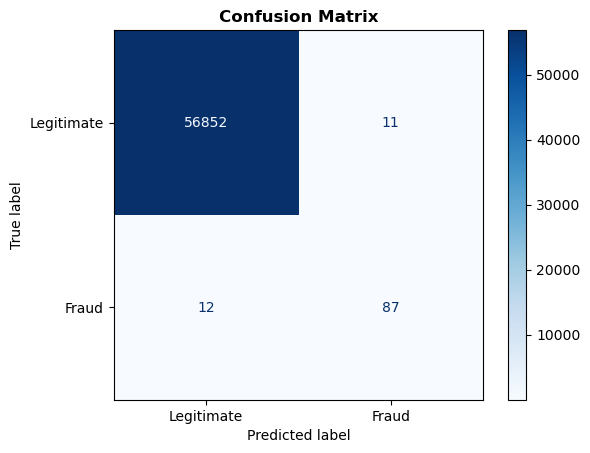

In [41]:
#CM visualization
cm = confusion_matrix(y_pred, y_test)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraud']).plot(cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')
plt.show()

### Model Performance
Out of 56962 transactions in the test set:
- **Frauds in test set**: 99 transactions
- **Frauds caught**: 87 (88% recall)
- **Frauds missed**: 12 (12% missed rate)
- **False alarms**: 11 (89% precision)

## Conclusions & Future Work
### Project Summary
Successfully developed a random forest classifier for credit card fraud detection, achieving:
- **88% Recall**: Catches 88 out of every 100 fraudulent transactions
- **89% Precision**: 89% of flagged transactions are actual frauds
- **88% F1-Score**

### Key Learnings
1. **Class imbalance is critical**: standard approaches will fail with 580:1 imbalance. In this project, SMOTE was essential for improving minority class detection
2. **Feature Quality matters**: PCA-transformed V features contained high information, eliminating the need for further feature engineering
3. **Tree-Based Models**: baseline random forest was proven to be able to handle imbalance dataset of fraudulent activities even with no tuning

### Limitations
1. **Interpretability**: due to most of the features are PCA-transformed V features, model interpretability are limited and it is difficult to explain specific decisions based on the result.
2. **Machine capabilities**: due to computational constraints, *max_depth = None* was excluded from the hyperparameter search space during tuning. However, baseline Random Forest, which uses *max_depth = None* by default, outperformed the tuned model, suggesting that unconstrained tree depth may be beneficial for this dataset.

### Future Improvements
1. Create an ensemble model of Random Forest with others, such as XGBoost, for potential improvement
2. Perform calculations on a machine with greater computational resources, allowing *max_depth = None* to be included as a candidate value for hyperparameter tuning